
# 🎯 0. Εισαγωγή στο RAG

Το **Retrieval-Augmented Generation (RAG)** είναι η πιο διαδεδομένη τεχνική για να συνδέσουμε ένα Large Language Model (LLM) με **εξωτερική γνώση** — αρχεία, βάσεις δεδομένων, APIs — που το μοντέλο δεν είδε ποτέ κατά την εκπαίδευσή του.

Αυτό το notebook απαντά τρεις ερωτήσεις:

1. **Γιατί** χρειαζόμαστε το RAG;
2. **Πώς** δουλεύει αρχιτεκτονικά;
3. **Πώς** χτίζουμε ένα minimal RAG σύστημα σε λιγότερο από 30 γραμμές;

> 💡 Όλα τα notebooks της σειράς χρησιμοποιούν το μοντέλο **`gpt-4o-mini`** της OpenAI — γρήγορο, οικονομικό και αρκετά δυνατό για εκπαιδευτικούς σκοπούς.

## 0.1 Το Πρόβλημα: Τι δεν ξέρει ένα LLM

Ένα LLM εκπαιδεύεται μία φορά πάνω σε ένα τεράστιο, αλλά **πεπερασμένο** corpus. Από εκείνη τη στιγμή και μετά, αδυνατεί να απαντήσει σωστά για:

| Κατηγορία γνώσης | Παράδειγμα ερώτησης | Γιατί αποτυγχάνει |
|---|---|---|
| 🆕 **Πρόσφατα γεγονότα** | «Ποιος κέρδισε το χθεσινό αγώνα;» | Δεδομένα μετά το cutoff του training |
| 🔒 **Ιδιωτικά / εταιρικά** | «Τι λέει το policy της εταιρείας μου;» | Δεν είδε ποτέ τα έγγραφά μας |
| 🎯 **Niche τεχνικά** | «Πώς ρυθμίζω το X-config v3.2;» | Πολύ εξειδικευμένο για να το έχει εσωτερικεύσει |
| 🔢 **Ακριβή νούμερα** | «Ποιο ήταν το GMV μας τον Μάρτιο;» | Δεν διαθέτει την πρωτογενή πηγή |

Όταν το LLM δεν ξέρει, συχνά **«hallucinates»** — επινοεί απαντήσεις που ακούγονται πειστικές αλλά είναι ψευδείς. Αυτό είναι το #1 πρόβλημα παραγωγής.

## 0.2 Τρεις Στρατηγικές Επίλυσης

Όταν θέλουμε ένα LLM να μιλά για νέα ή ιδιωτικά δεδομένα, έχουμε τρεις δρόμους:

| Προσέγγιση | Πώς δουλεύει | Κόστος | Πότε ταιριάζει |
|---|---|---|---|
| **Prompting** | Βάζουμε όλη τη γνώση μέσα στο prompt | Χαμηλό | Μικρά, στατικά κείμενα |
| **Fine-tuning** | Επανεκπαιδεύουμε το μοντέλο | Πολύ υψηλό | Νέο **στυλ** ή νέα **format** συμπεριφορά |
| **RAG** | Κάθε query → ψάχνει σχετικά docs → τα βάζει στο prompt | Μέτριο | **Factual recall** πάνω σε μεταβαλλόμενα δεδομένα |

**Vital insight:** Το fine-tuning είναι κατάλληλο για να αλλάξεις πώς **σκέφτεται/μιλά** το μοντέλο, όχι για να του διδάξεις **νέα γεγονότα**. Για γεγονότα → RAG.

> 💡 **Βασική αρχή:** Το LLM δεν αλλάζει — αλλάζει μόνο το *prompt* που του δίνουμε. Το RAG χτίζει αυτό το prompt δυναμικά.

## 0.3 Η Αρχιτεκτονική με μία ματιά

Το RAG αποτελείται από **δύο φάσεις**:

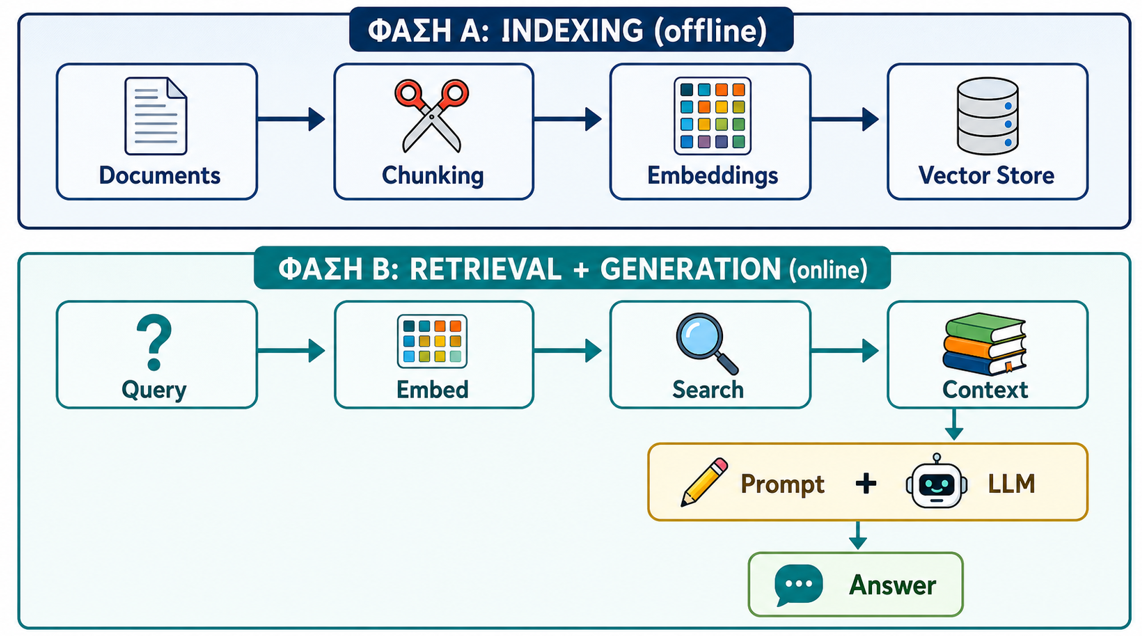

**Φάση Α (Indexing)** τρέχει **μία φορά** (ή όποτε αλλάζουν τα docs):
1. Φορτώνουμε documents από οποιαδήποτε πηγή
2. Τα κόβουμε σε μικρά chunks
3. Μετατρέπουμε κάθε chunk σε ένα **embedding vector** (αριθμητικό fingerprint)
4. Αποθηκεύουμε τα vectors σε μια vector database

**Φάση Β (Retrieval + Generation)** τρέχει **σε κάθε ερώτηση**:
1. Παίρνουμε την ερώτηση και την κάνουμε επίσης embedding
2. Ψάχνουμε στη vector DB τα **k πιο όμοια** chunks
3. Τα βάζουμε ως **context** σε ένα prompt template
4. Στέλνουμε το prompt στο LLM για να μας δώσει την τελική απάντηση

<img src="images/rag_architecture_overview.png" width="80%" style="border-radius:10px;margin:12px 0;"/>

***Εικ. 0.1** — Οι δύο φάσεις RAG: Indexing (offline) και Retrieval+Generation (online, ανά query).*

## 0.4 Setup του περιβάλλοντος

Όλα τα notebooks της σειράς απαιτούν:

* `langchain` — το framework για LLM apps
* `langchain-openai` — integration με OpenAI
* `langchain-community` — extra loaders/utilities
* `chromadb` — μια απλή local vector store
* `tiktoken` — για να μετράμε tokens

Αν τρέχεις τοπικά: αφαίρεσε το `#` από την επόμενη γραμμή.

In [ ]:
# !pip install -q langchain langchain-openai langchain-community langchain-chroma chromadb tiktoken
# (Run once if packages are not already installed)


### API key

Χρειαζόμαστε ένα **OpenAI API key**. Ποτέ μην το βάλεις hardcoded σε αρχείο — χρησιμοποίησε `getpass` ή environment variable.

https://developers.openai.com/api/docs/guides/embeddings

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

_env_path = Path(".env")
load_dotenv(dotenv_path=_env_path, override=False)

LLM_MODEL = "gpt-4o-mini"

> 🔑 **Βασική αρχή:** Το LLM δεν αλλάζει — αλλάζει μόνο το *prompt* που του δίνουμε. Το RAG είναι ουσιαστικά ένας έξυπνος τρόπος να χτίσουμε αυτό το prompt δυναμικά.

## 0.5 Ένα LLM χωρίς context — αποτυγχάνει

Πριν δούμε RAG, ας δούμε γιατί το χρειαζόμαστε. Θα ρωτήσουμε το `gpt-4o-mini` για ένα φανταστικό προϊόν της εταιρείας **S-RAG** που το μοντέλο δεν έχει δει ποτέ.

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model=LLM_MODEL, temperature=0.0)

response = llm.invoke("What is the price of the Datanous Insight Professional plan and what is included?")

print(f"Response: {response.content}")

Response: As of my last update in October 2023, I don't have specific pricing information for Datanous Insight's Professional plan or its features. Pricing and plan details can change frequently, so I recommend visiting the official Datanous website or contacting their customer support for the most accurate and up-to-date information regarding their plans and what is included in each.


Το μοντέλο είτε θα παραδεχθεί ότι δεν ξέρει, είτε — χειρότερα — θα **επινοήσει** μια απάντηση. Καμία από τις δύο δεν είναι αυτό που θέλουμε στην παραγωγή.

Ας του δώσουμε **τη γνώση που του λείπει** μέσω RAG.

## 0.6 Hello World RAG — σε 6 βήματα

Θα φτιάξουμε ένα minimal end-to-end RAG πάνω σε μια μικρή knowledge base για το S-RAG.
Στα επόμενα notebooks θα εμβαθύνουμε σε **κάθε** βήμα — εδώ θέλουμε απλώς να δούμε το συνολικό σχήμα.

### Βήμα 1: Τα δεδομένα μας

Σε ένα πραγματικό σύστημα τα docs έρχονται από PDFs, Confluence, Notion, websites κ.λπ. Εδώ φτιάχνουμε μια μικρή λίστα από plain strings — αρκετά για να δούμε τη μηχανική.

In [4]:
datanous_documents = [
    "Datanous.ai is an AI services company founded in 2021 and headquartered in Athens, Greece, "
    "with offices in London and Amsterdam. The company employs 85 engineers and data scientists.",
 
    "Datanous Insight is a RAG-powered knowledge management platform. It ingests documents in PDF, "
    "Word, Markdown, and plain-text formats, indexes them with a hybrid retrieval pipeline, "
    "and answers staff queries through a natural language interface with source citations.",
 
    "Datanous Insight pricing: Starter plan costs 50 USD per month and supports up to 10,000 "
    "document pages with single-tenant isolation. Professional plan costs 350 USD per month "
    "and supports up to 100,000 pages with multi-tenant row-level access control. "
    "Enterprise plan offers unlimited pages, a dedicated vector store, and a 99.9 percent "
    "uptime SLA at custom pricing.",
 
    "Datanous Search is a standalone hybrid search API. It combines BM25 lexical retrieval with "
    "dense semantic embeddings and merges results using Reciprocal Rank Fusion. A cross-encoder "
    "reranker then selects the final top-k results. Latency over one million document chunks "
    "is under 200 milliseconds at the 95th percentile.",
 
    "Datanous Guard is an AI governance middleware that performs four checks on every request: "
    "(1) factual grounding verification, (2) prompt injection detection, "
    "(3) PII redaction of names, emails, and ID numbers, (4) tenant isolation by tenant_id. "
    "It is available as a LangChain-compatible RunnableLambda.",
 
    "Datanous Embed is a managed embeddings API that supports text-embedding-3-small (1536 dimensions) "
    "and text-embedding-3-large (3072 dimensions). Batch requests of up to 2048 texts are processed "
    "in parallel. A Redis cache reduces repeated embedding costs; cache hit rate on enterprise "
    "corpora typically exceeds 60 percent.",
 
    "Datanous.ai serves clients in banking, legal services, healthcare, and media across Europe. "
    "A law firm deployment reduced document search time from 2.5 hours to 8 minutes and achieved "
    "91 percent retrieval faithfulness. A retail bank deployment cut regulatory query resolution "
    "from 4 days to under 30 seconds.",
]

print(f"Knowledge base: {len(datanous_documents)} documents")
for i, d in enumerate(datanous_documents):
    print(f" [{i+1}] {d[:80]}...")

Knowledge base: 7 documents
 [1] Datanous.ai is an AI services company founded in 2021 and headquartered in Athen...
 [2] Datanous Insight is a RAG-powered knowledge management platform. It ingests docu...
 [3] Datanous Insight pricing: Starter plan costs 50 USD per month and supports up to...
 [4] Datanous Search is a standalone hybrid search API. It combines BM25 lexical retr...
 [5] Datanous Guard is an AI governance middleware that performs four checks on every...
 [6] Datanous Embed is a managed embeddings API that supports text-embedding-3-small ...
 [7] Datanous.ai serves clients in banking, legal services, healthcare, and media acr...


### Βήμα 2: Embedding model

Το embedding model μετατρέπει κείμενο σε ένα **vector** (πχ. 1536 αριθμοί). Κείμενα με παρόμοιο νόημα δίνουν vectors που είναι **κοντά** στον χώρο.

Στο notebook 01 θα εμβαθύνουμε στο πώς και γιατί δουλεύει.

In [5]:
from langchain_openai import OpenAIEmbeddings

# The same embedding models must be used for indexing and quering!!!
# text-embedding-3-small : 1536 dimensions, fast, cost-effective

EMBED_MODEL = "text-embedding-3-small"

embedder = OpenAIEmbeddings(model=EMBED_MODEL)

sample_vector = embedder.embed_query("What is datanous insight?")

print(f"Vector dimensions: {len(sample_vector)}")
print(f"First 5 values: {[round(v, 4) for v in sample_vector[:5]]}")

Vector dimensions: 1536
First 5 values: [0.0197, -0.0102, 0.0073, 0.0234, 0.0101]


### Βήμα 3: Vector store (το «βιβλίο διευθύνσεων» των vectors)

In [6]:
from langchain_chroma import Chroma
from langchain_core.documents import Document

kb = [
    Document(
        page_content="Datanous.ai is an AI services company founded in 2021 in Athens, Greece, "
                     "with offices in London and Amsterdam. The company employs 85 engineers.",
        metadata={"source": "datanous_overview.txt", "section": "company"},
    ),
    Document(
        page_content="Datanous Insight is a RAG-powered knowledge management platform that indexes "
                     "enterprise documents and answers queries through a natural language interface "
                     "with source citations.",
        metadata={"source": "datanous_products.txt", "product": "Insight"},
    ),
    Document(
        page_content="Datanous Insight pricing: Starter 50 USD/month (10,000 pages), "
                     "Professional 350 USD/month (100,000 pages, multi-tenant access control), "
                     "Enterprise unlimited pages with 99.9 percent uptime SLA.",
        metadata={"source": "datanous_products.txt", "section": "pricing"},
    ),
    Document(
        page_content="Datanous Search combines BM25 lexical retrieval with dense semantic embeddings "
                     "and applies cross-encoder reranking via Reciprocal Rank Fusion. "
                     "Latency under 200 ms at the 95th percentile over one million chunks.",
        metadata={"source": "datanous_products.txt", "product": "Search"},
    ),
    Document(
        page_content="Datanous Guard performs four checks: factual grounding, prompt injection "
                     "detection, PII redaction, and tenant isolation by tenant_id filtering.",
        metadata={"source": "datanous_products.txt", "product": "Guard"},
    ),
    Document(
        page_content="Datanous Embed supports text-embedding-3-small (1536 dims) and "
                     "text-embedding-3-large (3072 dims) with Redis caching. "
                     "Cache hit rate on enterprise corpora typically exceeds 60 percent.",
        metadata={"source": "datanous_products.txt", "product": "Embed"},
    ),
    Document(
        page_content="Datanous.ai serves clients in banking, legal, healthcare, and media across Europe. "
                     "A law firm deployment reduced document search time from 2.5 hours to 8 minutes. "
                     "A retail bank deployment cut query resolution from 4 days to 30 seconds.",
        metadata={"source": "datanous_case_studies.txt", "section": "results"},
    ),
]

# Build the vector store (Chroma in memory)
vectore_store = Chroma.from_documents(kb, embedding=embedder)
print(f"Vector-store created with: {vectore_store._collection.count()} document chunks.")

Vector-store created with: 7 document chunks.


### Βήμα 4: Retriever

Ο retriever είναι απλώς μια διεπαφή που, δοθείσης μιας ερώτησης, επιστρέφει τα πιο σχετικά documents.

In [ ]:
retriever = vectore_store.as_retriever(search_kwargs = {"k": 3})

test_query = "What is the price of the Professional plan?"
retrieved = retriever.invoke(test_query)

print(f"Query: {test_query}")
print(f"Retriever documents: {len(retrieved)}")

for doc in retrieved:
    print(f" [{doc.metadata.get('product',  doc.metadata.get('section', ''))}]"
          f"{doc.page_content[:100]}...")

Query: What is the price of the Professional plan?
Retriever documents: 4
 [pricing]Datanous Insight pricing: Starter 50 USD/month (10,000 pages), Professional 350 USD/month (100,000 p...
 [results]Datanous.ai serves clients in banking, legal, healthcare, and media across Europe. A law firm deploy...
 [Embed]Datanous Embed supports text-embedding-3-small (1536 dims) and text-embedding-3-large (3072 dims) wi...
 [Insight]Datanous Insight is a RAG-powered knowledge management platform that indexes enterprise documents an...


### Βήμα 5: Prompt template

Δίνουμε στο LLM μια οδηγία: «απάντησε **μόνο** βάσει του παρακάτω context». Αυτό μειώνει δραστικά τα hallucinations.

In [9]:
from langchain_core.prompts import ChatPromptTemplate

RAG_PROMPT = ChatPromptTemplate.from_template(
    '''You are a helpful assistant for Datanous.ai
    Answer the question using ONLY the information provided in the context below.
    If the answer is not in the context, respond with: "I don't have the information.
    
    Context:
    {context}
    
    Question: {question}
    
    Answer:'''
)

print(f"Variables expected: {RAG_PROMPT.input_variables}")

Variables expected: ['context', 'question']


### Βήμα 6: Συναρμολόγηση της αλυσίδας (LCEL)

Το **LangChain Expression Language (LCEL)** μας επιτρέπει να συνδέουμε components με τον τελεστή `|` σαν Unix pipes.

In [10]:
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

llm = ChatOpenAI(model=LLM_MODEL, temperature=0.0)

rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | RAG_PROMPT
    | llm
    | StrOutputParser()
)

answer = rag_chain.invoke("What is datanous insights?")
print(f"Answer: {answer}")

Answer: Datanous Insight is a RAG-powered knowledge management platform that indexes enterprise documents and answers queries through a natural language interface with source citations.


🎉 Δουλεύει! Παρατηρήσε ότι η απάντηση είναι **factual**, **αναφέρεται στα δικά μας docs** και **δεν** την επινοεί το LLM.

Ας δοκιμάσουμε μερικές ακόμα ερωτήσεις για να επιβεβαιώσουμε:

In [11]:
# Test the RAG chain with several questions about Datanous.ai
questions = [
    "What is the price of the Datanous Insight Professional plan?",
    "What does Datanous Guard protect against?",
    "Which industries does Datanous.ai serve?",
    "What is the cache hit rate of Datanous Embed on enterprise corpora?",
    "What is the price of a Netflix Premium subscription?",  # Outside the knowledge base
]
 
for q in questions:
    print(f"Q: {q}")
    print(f"A: {rag_chain.invoke(q)}")
    print()

Q: What is the price of the Datanous Insight Professional plan?
A: The price of the Datanous Insight Professional plan is 350 USD/month.

Q: What does Datanous Guard protect against?
A: Datanous Guard protects against factual grounding, prompt injection detection, PII redaction, and tenant isolation by tenant_id filtering.

Q: Which industries does Datanous.ai serve?
A: Datanous.ai serves clients in banking, legal, healthcare, and media across Europe.

Q: What is the cache hit rate of Datanous Embed on enterprise corpora?
A: Cache hit rate on enterprise corpora typically exceeds 60 percent.

Q: What is the price of a Netflix Premium subscription?
A: I don't have the information.



Στη τέταρτη ερώτηση το σύστημα **παραδέχτηκε** ότι δεν ξέρει, αντί να επινοήσει. Αυτό είναι ένα από τα μεγάλα πλεονεκτήματα του καλά σχεδιασμένου RAG.

## 0.7 Πότε **δεν** ταιριάζει το RAG

Το RAG δεν είναι ασημένια σφαίρα. Δεν ταιριάζει όταν:

| Σενάριο | Καλύτερη επιλογή |
|---|---|
| Θέλω το μοντέλο να γράφει σε ένα **συγκεκριμένο style** | Fine-tuning ή system prompt |
| Η απάντηση απαιτεί **πραγματικό computation** (μαθηματικά, SQL) | Tool calling / function calling |
| Όλη η γνώση μου χωρά **άνετα στο context window** | Απλό prompting |
| Χρειάζομαι **multi-step reasoning** πάνω σε external state | Agent με tools (RAG μπορεί να είναι ένα tool) |

Συχνά η **καλύτερη αρχιτεκτονική** είναι **υβριδική**: ένας agent που έχει RAG ως ένα tool, αλλά μπορεί επίσης να καλέσει APIs, να τρέξει code κ.λπ.

## 0.8 Ορολογία cheat-sheet

| Όρος | Τι σημαίνει |
|---|---|
| **Document** | Ένα κείμενο (αρχείο, web page, paragraph) με `page_content` και `metadata` |
| **Chunk** | Ένα μικρό κομμάτι document που στέλνουμε ως embedding |
| **Embedding** | Vector αριθμών που αναπαριστά το νόημα ενός κειμένου |
| **Vector store** | Database που κάνει similarity search σε vectors |
| **Retriever** | Διεπαφή που, δοθείσης μιας ερώτησης, επιστρέφει σχετικά chunks |
| **Context window** | Το maximum tokens που χωρά ένα LLM σε ένα prompt |
| **Hallucination** | Όταν το LLM παράγει εσφαλμένη πληροφορία με αυτοπεποίθηση |
| **LCEL** | LangChain Expression Language — για composition με τον `\|` |
| **k** | Πόσα top documents επιστρέφει ο retriever |

## 0.9 Άσκηση

**Άσκηση 1:** Πρόσθεσε ένα νέο document στο knowledge base που λέει ότι «το S-RAG Quantum Database είναι σε beta και προσφέρεται δωρεάν μέχρι το τέλος του 2026». Στη συνέχεια ξαναφτιάξε το vector store και ρώτα: *«Πότε λήγει το beta του Quantum Database;»*

## 📋 Συμπεράσματα

| # | Έννοια | Συνοπτικά |
|---|---|---|
| 1 | RAG | Συνδέει LLM με εξωτερική, μεταβαλλόμενη γνώση |
| 2 | Πρόβλημα | LLMs αγνοούν: πρόσφατα γεγονότα, ιδιωτικά δεδομένα, niche τεχνικά |
| 3 | Hallucination | Όταν το LLM επινοεί πειστικές αλλά λάθος απαντήσεις |
| 4 | RAG vs Fine-tuning | Fine-tuning = αλλαγή στυλ, RAG = αλλαγή γεγονότων |
| 5 | Φάση Α: Indexing | Documents → Chunks → Embeddings → Vector Store |
| 6 | Φάση Β: Retrieval+Gen | Query → Embed → Search → Context → LLM → Answer |
| 7 | Embedding | Numerical fingerprint του νοήματος ενός κειμένου |
| 8 | Retriever | `k` πιο σχετικά chunks για μια ερώτηση |
| 9 | Prompt design | «Απάντησε μόνο από το context» μειώνει hallucinations |
| 10 | LCEL | Σύνδεση components με `\|` (όπως Unix pipes) |
| 11 | Πότε όχι RAG | Style changes, computation, agentic flows |
| 12 | Επόμενο βήμα | Notebook 01 — βαθιά κατανόηση του Indexing |